In [43]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
    print(f.keys())

    R = f["R3"]
    print(R.keys())
    print(R["wall"].keys())
    print(R["wall"]["tau_mean_a"])
    print(f["R3"]["t"][:5])
    print(f["R13"]["t"][:5])

<KeysViewHDF5 ['R13', 'R14', 'R15', 'R18', 'R19', 'R21', 'R22', 'R23', 'R26', 'R28', 'R3', 'R4', 'R5', 'Ubase_laminar', 'Ubase_periodic_mean', 'readme', 'x', 'y', 'z']>
<KeysViewHDF5 ['is_turbulent', 'p_rapid', 'p_slow', 'p_stokes', 'p_total', 't', 'u', 'v', 'w', 'wall']>
<KeysViewHDF5 ['dudy_a', 'dudy_b', 'dwdy_a', 'dwdy_b', 'p_rapid_a', 'p_rapid_b', 'p_slow_a', 'p_slow_b', 'p_stokes_a', 'p_stokes_b', 'p_total_a', 'p_total_b', 'tau_mean_a', 'tau_mean_b']>
<HDF5 dataset "tau_mean_a": shape (4801,), type "<f4">
[200. 201. 202. 203. 204.]
[208. 224. 240. 256. 272.]


In [44]:
keys = 'u', 'v', 'w', 'p_total'
def extract(real, keys):
    data = []
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data.append(np.array(f[real][k]))
        return np.stack(data, axis=1)

In [45]:
d = extract('R3', keys)

In [46]:
d.shape

(4801, 4, 24, 33, 24)

In [47]:
d_hat = np.fft.fft2(d[::], axes=(2, 4))

In [48]:
# check
_m = d[::].sum(axis=(2, 4), keepdims=True)
_m.shape

(4801, 4, 1, 33, 1)

In [49]:
np.abs(_m - d_hat[:, :, 0, :, 0][:, :, None, :, None]).max()

np.float32(0.00012207031)

In [50]:
means = d.mean(axis=(0, 2, 4), keepdims=True)

In [51]:
means.shape

(1, 4, 1, 33, 1)

In [52]:
flucts = d[::] - means

In [53]:
d_hat.shape

(4801, 4, 24, 33, 24)

In [54]:
d_flucts_hat = np.fft.fft2(flucts, axes=(2, 4))

In [55]:
mean_power = np.abs(d_hat[:, 0, :, 1, :].mean((0))) ** 2

In [56]:
def plot_powers(mean_power):
    shifted = np.fft.fftshift(mean_power)   # reorders so zero-frequency is centered
    
    plt.imshow(np.log10(shifted + 1e-20), origin='lower', cmap='viridis')
    plt.colorbar(label='log10(power)')
    plt.xlabel('kz index')
    plt.ylabel('kx index')
    plt.show()

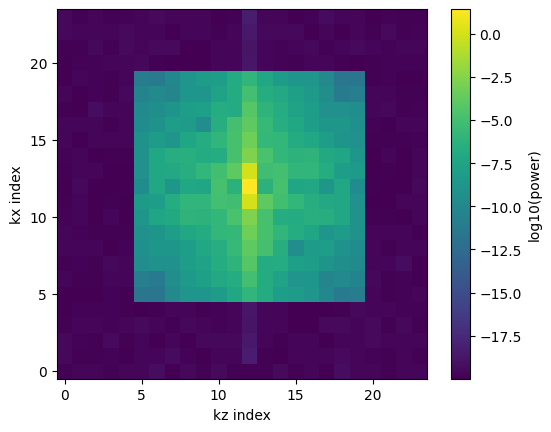

In [57]:
plot_powers(mean_power)

In [58]:
flucts_mean_power = np.abs(d_flucts_hat[:, 0, :, 1, :].mean((0))) ** 2

In [59]:
flucts_mean_power.max()

np.float32(1.0417274)

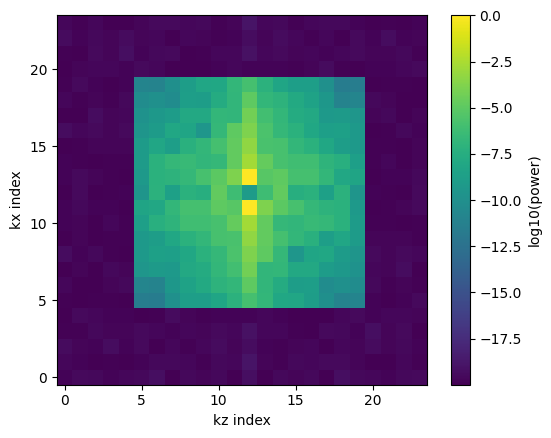

In [60]:
plot_powers(flucts_mean_power)

In [61]:
def domain():
    data = {}
    keys = ['x', 'y', 'z']
    with h5py.File("/data1/dataToYouri/couette_dns_ml_f32.h5", 'r') as f:
        for k in keys:
            data[k] = np.array(f[k])
        return data

In [62]:
domain = domain()

In [63]:
dx = domain['x'][1] - domain['x'][0]
dz = domain['z'][1] - domain['z'][0]
nx = domain['x'].shape[0]
nz = domain['z'].shape[0]
kx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2*np.pi
kz = np.fft.fftshift(np.fft.fftfreq(nz, d=dz)) * 2*np.pi

In [64]:

def energy_per_scale(mean_power):
    kx = np.fft.fftshift(np.fft.fftfreq(nx, d=dx)) * 2*np.pi
    kz = np.fft.fftshift(np.fft.fftfreq(nz, d=dz)) * 2*np.pi
    KX, KZ = np.meshgrid(kx, kz, indexing='ij')
    K = np.sqrt(KX**2 + KZ**2)
    
    power_shifted = np.fft.fftshift(mean_power)
    
    # bin into radial shells
    k_bins = np.linspace(0, K.max(), 20)
    k_centers = 0.5 * (k_bins[:-1] + k_bins[1:])
    radial_power = np.zeros(len(k_bins)-1)
    for i in range(len(k_bins)-1):
        mask = (K >= k_bins[i]) & (K < k_bins[i+1])
        radial_power[i] = power_shifted[mask].sum() if mask.any() else 0
    
    plt.plot(k_bins[:-1], radial_power)

    # Kolmogorov -5/3 reference, anchored to match data at one point
    valid = radial_power > 0
    k_ref, e_ref = k_centers[valid][len(k_centers[valid])//2], radial_power[valid][len(k_centers[valid])//2]
    k_line = k_centers[valid]
    e_line = e_ref * (k_line / k_ref) ** (-5/3)
    plt.plot(k_line, e_line, '--', label=r'$k^{-5/3}$')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('|k|')
    plt.ylabel('mean power')
    plt.legend()
    plt.show()

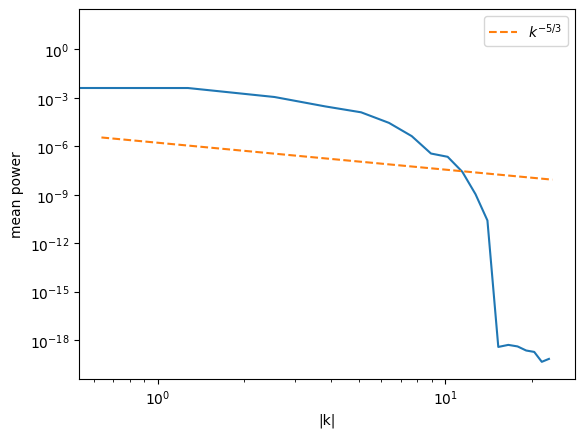

In [65]:
energy_per_scale(mean_power)

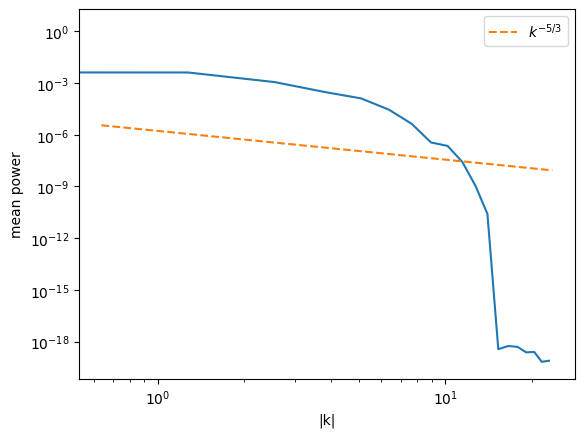

In [66]:
energy_per_scale(flucts_mean_power)

In [67]:
# ⟨p* . u⟩ - ⟨p⟩* . ⟨u⟩
# u, p of shape (...T, k...)
def cross_spectrum(p_hat, u_hat, avg_axis=(0,)):
    return np.mean(p_hat.conj() * u_hat, axis=avg_axis) - (np.mean(p_hat, axis=avg_axis).conj() * np.mean(u_hat, axis=avg_axis))
    
# coherence gamma2
# |Spu|2 / [ Spp Suu ]
def compute_coherence(p_hat, u_hat):
    Suu = cross_spectrum(u_hat, u_hat)
    Spu = cross_spectrum(p_hat, u_hat)
    Spp = cross_spectrum(p_hat, p_hat)

    return np.abs(Spu) ** 2 / (Suu * Spp)
    

In [68]:
pressure_hat = d_flucts_hat[:, 3, :, :, :]
coherence = compute_coherence(pressure_hat[:, :, 0, :][:, None, :, None, :], d_flucts_hat[:, :, :, 1:-1, :])

In [69]:
coherence.shape

(4, 24, 31, 24)

In [70]:
coherence.imag.sum()

np.float32(2.0363292e-07)

In [71]:
gamma2 = coherence.real

In [72]:
domain['y']

array([-1.00000000e+00, -9.95184727e-01, -9.80785280e-01, -9.56940336e-01,
       -9.23879533e-01, -8.81921264e-01, -8.31469612e-01, -7.73010453e-01,
       -7.07106781e-01, -6.34393284e-01, -5.55570233e-01, -4.71396737e-01,
       -3.82683432e-01, -2.90284677e-01, -1.95090322e-01, -9.80171403e-02,
        6.12323400e-17,  9.80171403e-02,  1.95090322e-01,  2.90284677e-01,
        3.82683432e-01,  4.71396737e-01,  5.55570233e-01,  6.34393284e-01,
        7.07106781e-01,  7.73010453e-01,  8.31469612e-01,  8.81921264e-01,
        9.23879533e-01,  9.56940336e-01,  9.80785280e-01,  9.95184727e-01,
        1.00000000e+00])

In [73]:
domain['y'].shape

(33,)

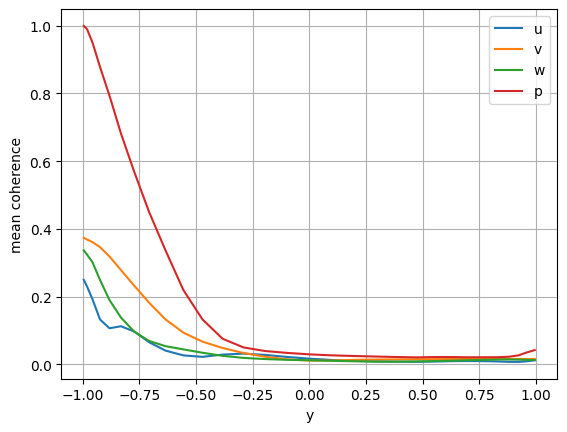

In [74]:
import matplotlib.pyplot as plt

y = domain['y'][1:-1]  # your wall-normal coordinate array, length 31, matching gamma2's y axis
comp_names = ['u', 'v', 'w', 'p']  # adjust to match your actual component ordering

fig, ax = plt.subplots()
for i, name in enumerate(comp_names):
    coh_y = gamma2[i].mean(axis=(0, 2))  # mean over kx, kz -> shape (y,)
    ax.plot(y, coh_y, label=name)

ax.set_xlabel('y')
ax.set_ylabel('mean coherence')
ax.legend()
plt.grid(True)
plt.show()

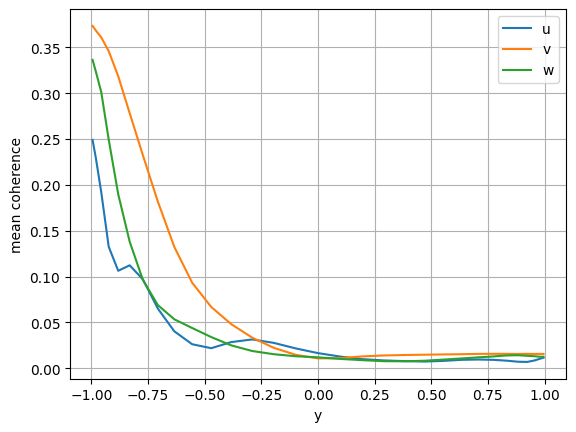

In [75]:
import matplotlib.pyplot as plt

y = domain['y'][1:-1]  # your wall-normal coordinate array, length 31, matching gamma2's y axis
comp_names = ['u', 'v', 'w']  # adjust to match your actual component ordering

fig, ax = plt.subplots()
for i, name in enumerate(comp_names):
    coh_y = gamma2[i].mean(axis=(0, 2))  # mean over kx, kz -> shape (y,)
    ax.plot(y, coh_y, label=name)

ax.set_xlabel('y')
ax.set_ylabel('mean coherence')
ax.legend()
plt.grid(True)
plt.show()

In [76]:
def plot_coherence_map(gamma2, comp_idx, y_idx, kx_freqs, kz_freqs, comp_name=''):
    data = gamma2[comp_idx, :, y_idx, :]           # shape (kx, kz)
    data_shifted = np.fft.fftshift(data, axes=(0, 1))
    kx_shifted = np.fft.fftshift(kx_freqs)
    kz_shifted = np.fft.fftshift(kz_freqs)

    plt.imshow(data_shifted, origin='lower', vmin=0, vmax=1, cmap='viridis',
               extent=[kz_shifted[0], kz_shifted[-1], kx_shifted[0], kx_shifted[-1]])
    plt.colorbar(label='coherence')
    plt.xlabel('kz'); plt.ylabel('kx')
    plt.title(f'{comp_name}, y_idx={y_idx}')
    plt.show()

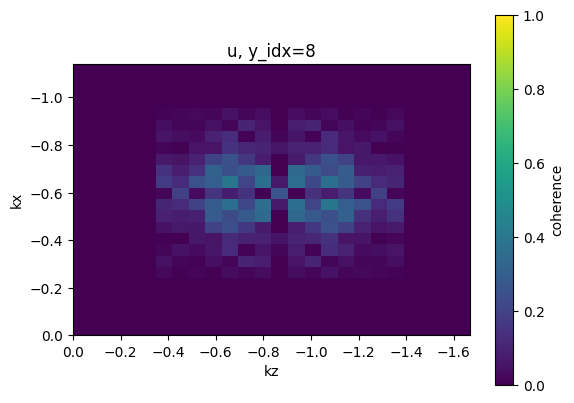

In [77]:
plot_coherence_map(gamma2, 0, 8, kx, kz, "u")

In [78]:
def plot_coherence_map_ax(gamma2, ax, comp_idx, y_idx, kx_freqs, kz_freqs, comp_name=''):
    data = gamma2[comp_idx, :, y_idx, :]           # shape (kx, kz)
    data_shifted = np.fft.fftshift(data, axes=(0, 1))
    kx_shifted = np.fft.fftshift(kx_freqs)
    kz_shifted = np.fft.fftshift(kz_freqs)

    ax.imshow(data_shifted, origin='lower', vmin=0, vmax=1, cmap='viridis',
               extent=[kz_shifted[0], kz_shifted[-1], kx_shifted[0], kx_shifted[-1]])
    ax.set_xlabel('kz'); plt.ylabel('kx')
    ax.set_title(f'{comp_name}, y_idx={y_idx}')


In [79]:
def plot_coherences(gamma2, y_idx, kx_freqs, kz_freqs,):
    fig, ax = plt.subplots(1, 3, figsize=(13, 5))
    plot_coherence_map_ax(gamma2, ax[0], 0, y_idx, kx_freqs, kz_freqs, 'u')
    plot_coherence_map_ax(gamma2, ax[1], 1, y_idx, kx_freqs, kz_freqs, 'v')
    plot_coherence_map_ax(gamma2, ax[2], 2, y_idx, kx_freqs, kz_freqs, 'w')
    plt.plot()
    

In [80]:
from ipywidgets import interact, FloatSlider
interact(lambda y_idx: plot_coherences(gamma2, y_idx, kx, kz), y_idx=(0, y.shape[0] - 1, 1));

interactive(children=(IntSlider(value=15, description='y_idx', max=30), Output()), _dom_classes=('widget-inter…

In [100]:
def reduced_coherence(gamma2, ax, comp, y_idx, kx, kz, comp_name):
    KX, KZ = np.meshgrid(kx, kz, indexing="ij")
    k_norm = np.sqrt(KX ** 2 + KZ ** 2)

    bins = np.linspace(0, k_norm.max() + 1e-10, 20)
    groups = [[] for _ in bins]
    for ix in range(len(kx)):
        for iz in range(len(kz)):
            for i, (b, bp1) in enumerate(zip(bins[:-1], bins[1:])):
                if b <= k_norm[ix, iz] < bp1:
                    groups[i].append(gamma2[comp, ix, y_idx, iz])
    means = np.array([np.mean(g) if len(g) > 0 else np.nan for g in groups])
    maxima = np.array([np.max(g) if len(g) > 0 else np.nan for g in groups])
    ax.plot(bins, means, label="means")
    ax.plot(bins, maxima, label="maxima")
    ax.set_ylim(0, 1)
    ax.set_title(comp_name)
    ax.legend()

In [103]:
def plot_reduced_coherences(gamma2, y_idx, kx_freqs, kz_freqs, ):
    fig, ax = plt.subplots(1, 3, figsize=(13, 5))
    reduced_coherence(gamma2, ax[0], 0, y_idx, kx, kz, "u")
    reduced_coherence(gamma2, ax[1], 1, y_idx, kx, kz, "v")
    reduced_coherence(gamma2, ax[2], 2, y_idx, kx, kz, "w")
    plt.plot()

In [104]:
interact(lambda y_idx: plot_reduced_coherences(gamma2, y_idx, kx, kz), y_idx=(0, y.shape[0] - 1, 1));

interactive(children=(IntSlider(value=15, description='y_idx', max=30), Output()), _dom_classes=('widget-inter…